# Crop Advisor: data cleaning and exploratory analysis

This notebook audits the supplied Crop Recommendation CSV files, prevents train/test leakage, creates a clean modeling dataset, and explores the relationships between soil, weather, and crop labels.

**Expected inputs**

- `data/raw/train.csv`
- `data/raw/test.csv`

**Generated output**

- `data/processed/crop_recommendation_clean.csv`
- EDA charts in `reports/figures/`

The supplied data contains nitrogen (`N`), phosphorus (`P`), potassium (`K`), `pH`, rainfall, temperature, and the target crop. It does **not** contain humidity or location.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")


def find_project_root(start: Path) -> Path:
    # Find the repository root whether run from the root or notebooks folder.
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw").exists():
            return candidate
    raise FileNotFoundError("Could not find data/raw. Run this notebook inside the Crop Advisor repository.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = RAW_DIR / "train.csv"
TEST_PATH = RAW_DIR / "test.csv"
CLEAN_PATH = PROCESSED_DIR / "crop_recommendation_clean.csv"

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\HP\Documents\Codex\2026-09-21\together-these-experiences-demonstrate-my-transition


## 1. Load and inspect the supplied files

We first verify the schema and compare the two files. This check is important because using overlapping records for training and testing would produce misleadingly high evaluation scores.

In [2]:
train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)

print(f"Train shape: {train_raw.shape}")
print(f"Test shape:  {test_raw.shape}")
display(train_raw.head())

schema = pd.DataFrame({
    "train_dtype": train_raw.dtypes.astype(str),
    "test_dtype": test_raw.dtypes.astype(str),
    "train_missing": train_raw.isna().sum(),
    "test_missing": test_raw.isna().sum(),
})
display(schema)

Train shape: (18079, 8)
Test shape:  (18079, 8)


,Unnamed: 0,Crop,N,P,K,pH,rainfall,temperature
0,10182,barley,70,40,45,5.540,75.320,22.676
1,16280,sunflower,50,60,30,5.540,297.660,29.567
2,54944,sweetpotato,90,20,120,5.020,689.880,29.037
3,98212,rice,80,40,40,5.660,297.660,29.567
4,52108,soyabean,20,60,20,5.380,"1,011.490",30.430


,train_dtype,test_dtype,train_missing,test_missing
Unnamed: 0,int64,int64,0,0
Crop,object,object,0,0
N,int64,int64,0,0
P,int64,int64,0,0
K,int64,int64,0,0
pH,float64,float64,0,0
rainfall,float64,float64,0,0
temperature,float64,float64,0,0


In [3]:
same_columns = train_raw.columns.tolist() == test_raw.columns.tolist()
sort_columns = train_raw.columns.tolist()
same_records = (
    train_raw.sort_values(sort_columns).reset_index(drop=True)
    .equals(test_raw.sort_values(sort_columns).reset_index(drop=True))
)

print(f"Same columns: {same_columns}")
print(f"Same records, ignoring row order: {same_records}")

if same_records:
    print("WARNING: Train and test are duplicate datasets in different row orders.")
    print("Cleaning will use train.csv once. A new stratified split must be created during model training.")
    source = train_raw.copy()
else:
    print("Files are distinct. Concatenating them for data-quality analysis only.")
    source = pd.concat([train_raw, test_raw], ignore_index=True)

Same columns: True
Same records, ignoring row order: True
Cleaning will use train.csv once. A new stratified split must be created during model training.


## 2. Clean the data

Cleaning rules:

1. Remove `Unnamed: 0`, which is an exported row index rather than a model feature.
2. Standardize crop labels by trimming whitespace and converting them to lowercase.
3. Convert all six model features to numeric values.
4. Reject missing values and impossible physical ranges.
5. Remove exact duplicate feature/target rows so identical observations cannot cross future data splits.

In [4]:
TARGET = "Crop"
FEATURES = ["N", "P", "K", "pH", "rainfall", "temperature"]
REQUIRED_COLUMNS = [TARGET, *FEATURES]

missing_columns = sorted(set(REQUIRED_COLUMNS) - set(source.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

data = source[REQUIRED_COLUMNS].copy()
data[TARGET] = data[TARGET].astype("string").str.strip().str.lower()

for column in FEATURES:
    data[column] = pd.to_numeric(data[column], errors="coerce")

quality_before = {
    "rows": len(data),
    "missing_cells": int(data.isna().sum().sum()),
    "duplicate_rows": int(data.duplicated(subset=REQUIRED_COLUMNS).sum()),
}
quality_before

{'rows': 18079, 'missing_cells': 0, 'duplicate_rows': 10914}

In [5]:
valid_ranges = (
    data["N"].ge(0)
    & data["P"].ge(0)
    & data["K"].ge(0)
    & data["pH"].between(0, 14)
    & data["rainfall"].ge(0)
    & data["temperature"].between(-20, 60)
)

invalid_rows = data.loc[~valid_ranges]
print(f"Rows outside broad physical ranges: {len(invalid_rows):,}")

clean = (
    data.loc[valid_ranges]
    .dropna(subset=REQUIRED_COLUMNS)
    .drop_duplicates(subset=REQUIRED_COLUMNS)
    .reset_index(drop=True)
)

quality_after = {
    "rows": len(clean),
    "missing_cells": int(clean.isna().sum().sum()),
    "duplicate_rows": int(clean.duplicated(subset=REQUIRED_COLUMNS).sum()),
    "crop_classes": int(clean[TARGET].nunique()),
}

display(pd.DataFrame([quality_before, quality_after], index=["before", "after"]))
clean.to_csv(CLEAN_PATH, index=False)
print(f"Saved cleaned data to: {CLEAN_PATH}")

Rows outside broad physical ranges: 0


,rows,missing_cells,duplicate_rows,crop_classes
before,18079,0,10914,NaN
after,7165,0,0,40.000


Saved cleaned data to: C:\Users\HP\Documents\Codex\2026-09-21\together-these-experiences-demonstrate-my-transition\data\processed\crop_recommendation_clean.csv


## 3. Summary statistics

These summaries help identify skew, extreme values, and scale differences that may influence model choice or preprocessing.

In [6]:
display(clean[FEATURES].describe().T)

class_counts = clean[TARGET].value_counts()
class_summary = class_counts.rename("records").to_frame()
class_summary["share_pct"] = 100 * class_summary["records"] / len(clean)
display(class_summary)

,count,mean,std,min,25%,50%,75%,max
N,"7,165.000",72.382,41.902,10.000,50.000,80.000,80.000,180.000
P,"7,165.000",44.613,15.275,10.000,40.000,40.000,60.000,125.000
K,"7,165.000",43.399,29.885,10.000,20.000,40.000,50.000,200.000
pH,"7,165.000",5.558,0.475,3.820,5.340,5.500,5.680,7.000
rainfall,"7,165.000",723.992,600.571,3.275,167.380,654.340,"1,111.680","3,322.060"
temperature,"7,165.000",26.142,4.954,1.180,22.891,26.736,28.680,35.347


,records,share_pct
Crop,,
rice,792,11.054
maize,668,9.323
moong,529,7.383
potato,461,6.434
onion,383,5.345
jowar,367,5.122
sunflower,362,5.052
rapeseed,361,5.038
cotton,297,4.145


## 4. Target distribution

The dataset is multiclass and imbalanced. Accuracy alone will therefore be insufficient; model comparison should also report macro F1 and balanced accuracy.

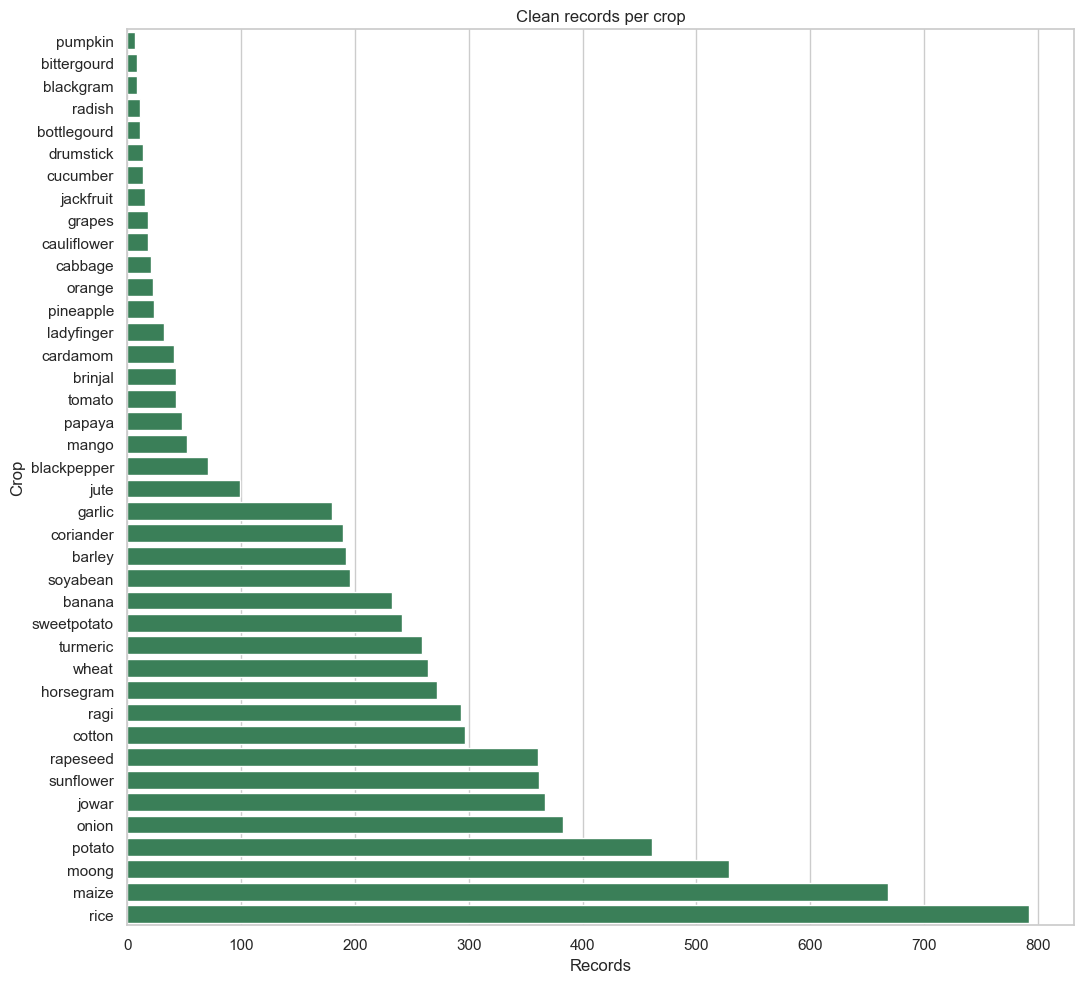

Largest/smallest class ratio: 113.1x


In [7]:
fig, ax = plt.subplots(figsize=(11, 10))
ordered_counts = class_counts.sort_values()
sns.barplot(x=ordered_counts.values, y=ordered_counts.index, ax=ax, color="#2E8B57")
ax.set(title="Clean records per crop", xlabel="Records", ylabel="Crop")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "crop_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Largest/smallest class ratio: {imbalance_ratio:.1f}x")

## 5. Feature distributions

Histograms show the overall shapes. Box plots make outliers and scale differences easier to see. Outliers are retained because unusual environmental conditions can be valid and tree-based models can handle them.

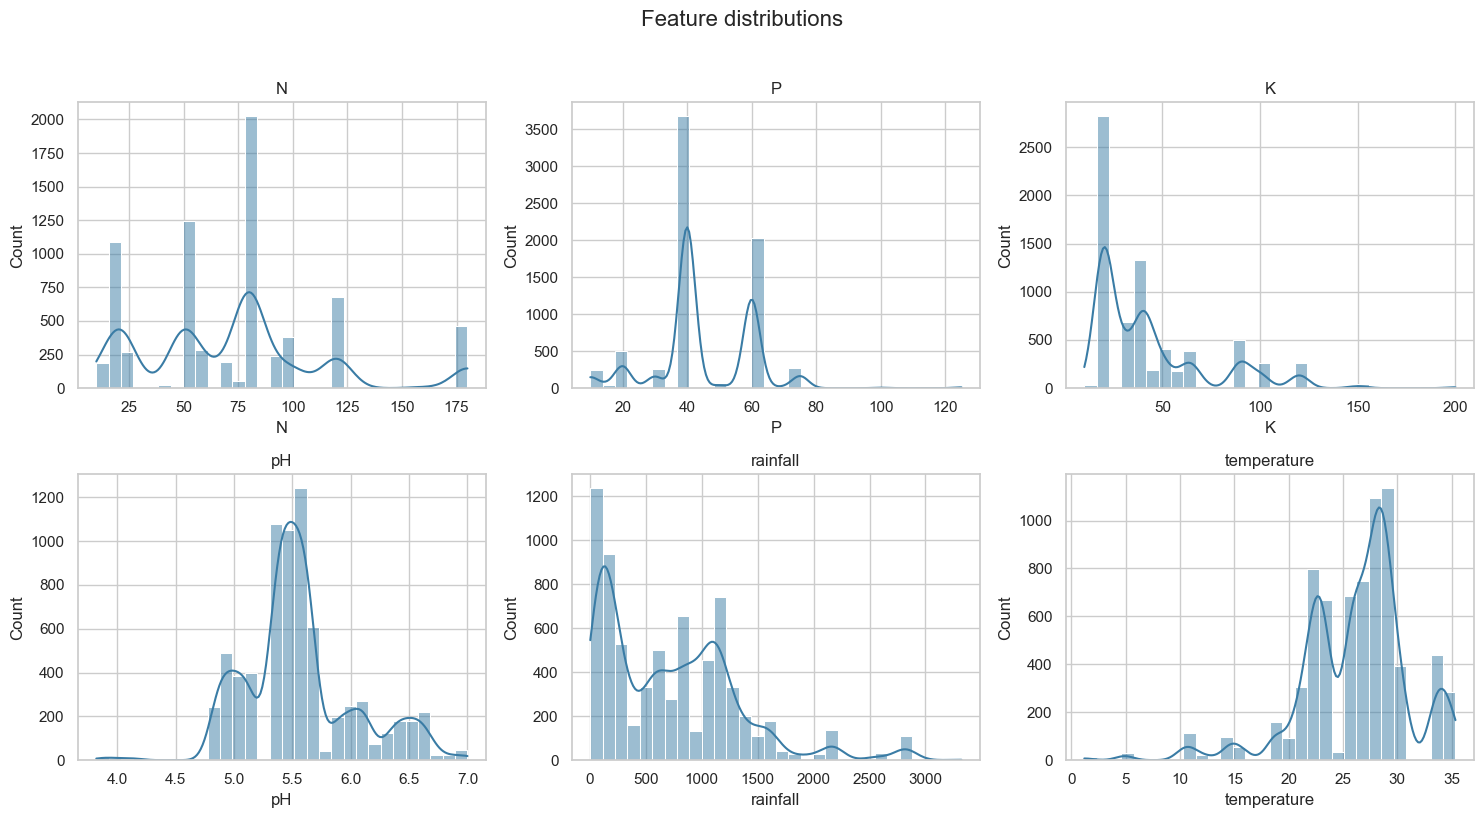

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for feature, ax in zip(FEATURES, axes.flat):
    sns.histplot(clean[feature], bins=30, kde=True, ax=ax, color="#3A7CA5")
    ax.set_title(feature)
fig.suptitle("Feature distributions", fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "feature_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

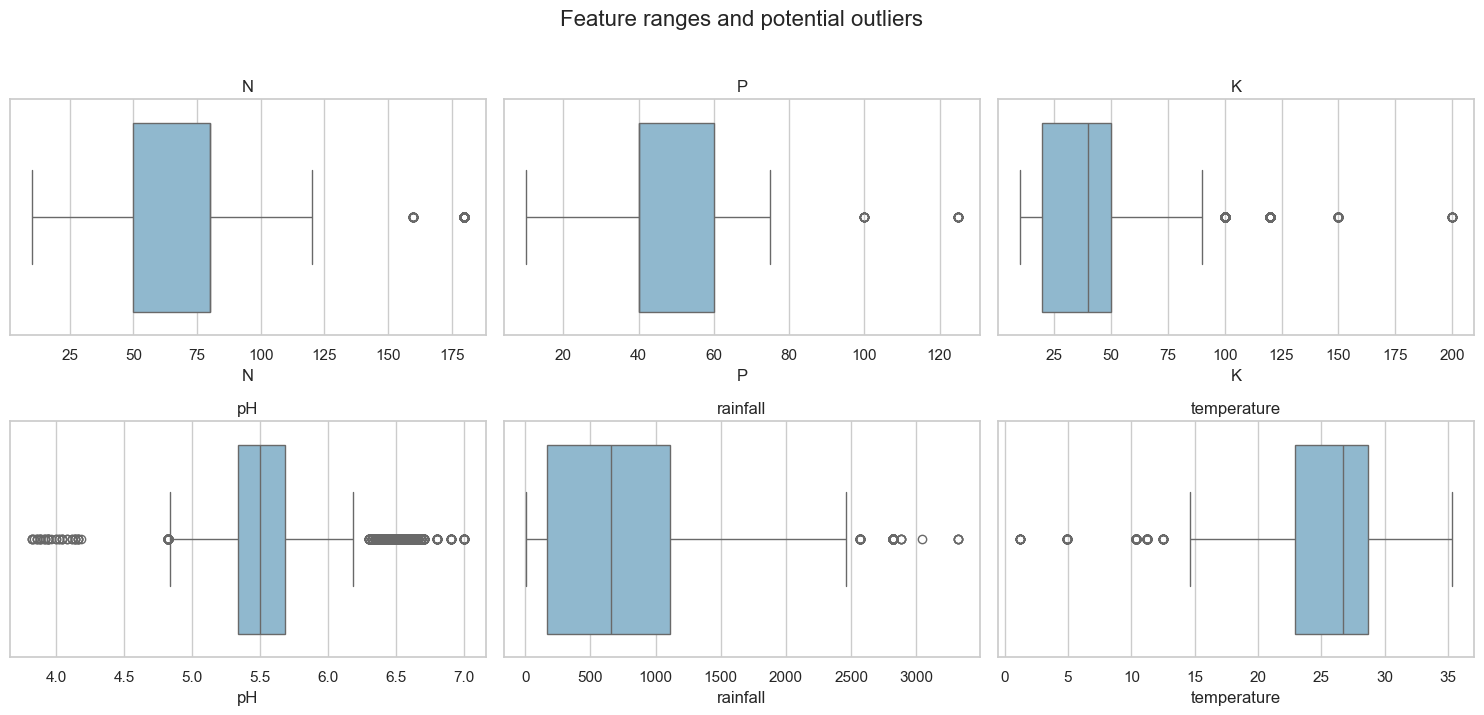

In [9]:
melted = clean[FEATURES].melt(var_name="feature", value_name="value")
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for feature, ax in zip(FEATURES, axes.flat):
    sns.boxplot(x=clean[feature], ax=ax, color="#86BBD8")
    ax.set_title(feature)
fig.suptitle("Feature ranges and potential outliers", fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "feature_boxplots.png", dpi=160, bbox_inches="tight")
plt.show()

## 6. Correlation analysis

Correlation measures linear association between numeric inputs. Strongly correlated inputs may be redundant for linear models, while weak correlation does not mean a feature is unhelpful for nonlinear models.

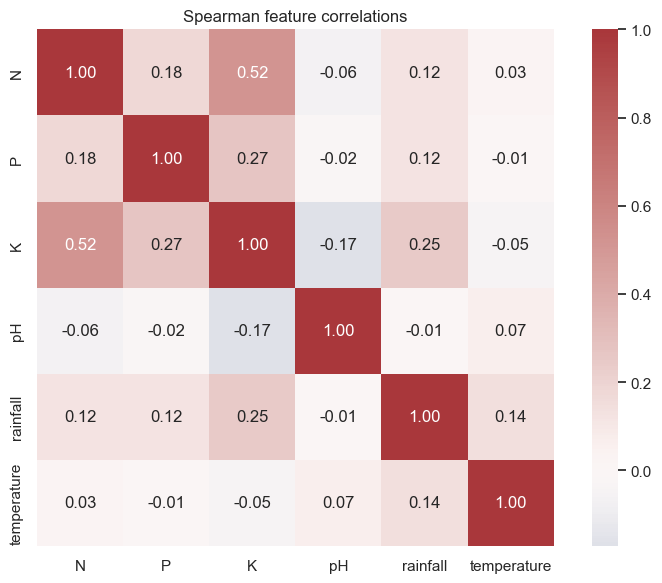

In [10]:
correlation = clean[FEATURES].corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="vlag", center=0, square=True, ax=ax)
ax.set_title("Spearman feature correlations")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "feature_correlations.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Crop-level feature patterns

The heatmap standardizes each feature across crop-level means. It highlights relative growing-condition profiles without letting large-unit variables such as rainfall dominate the chart.

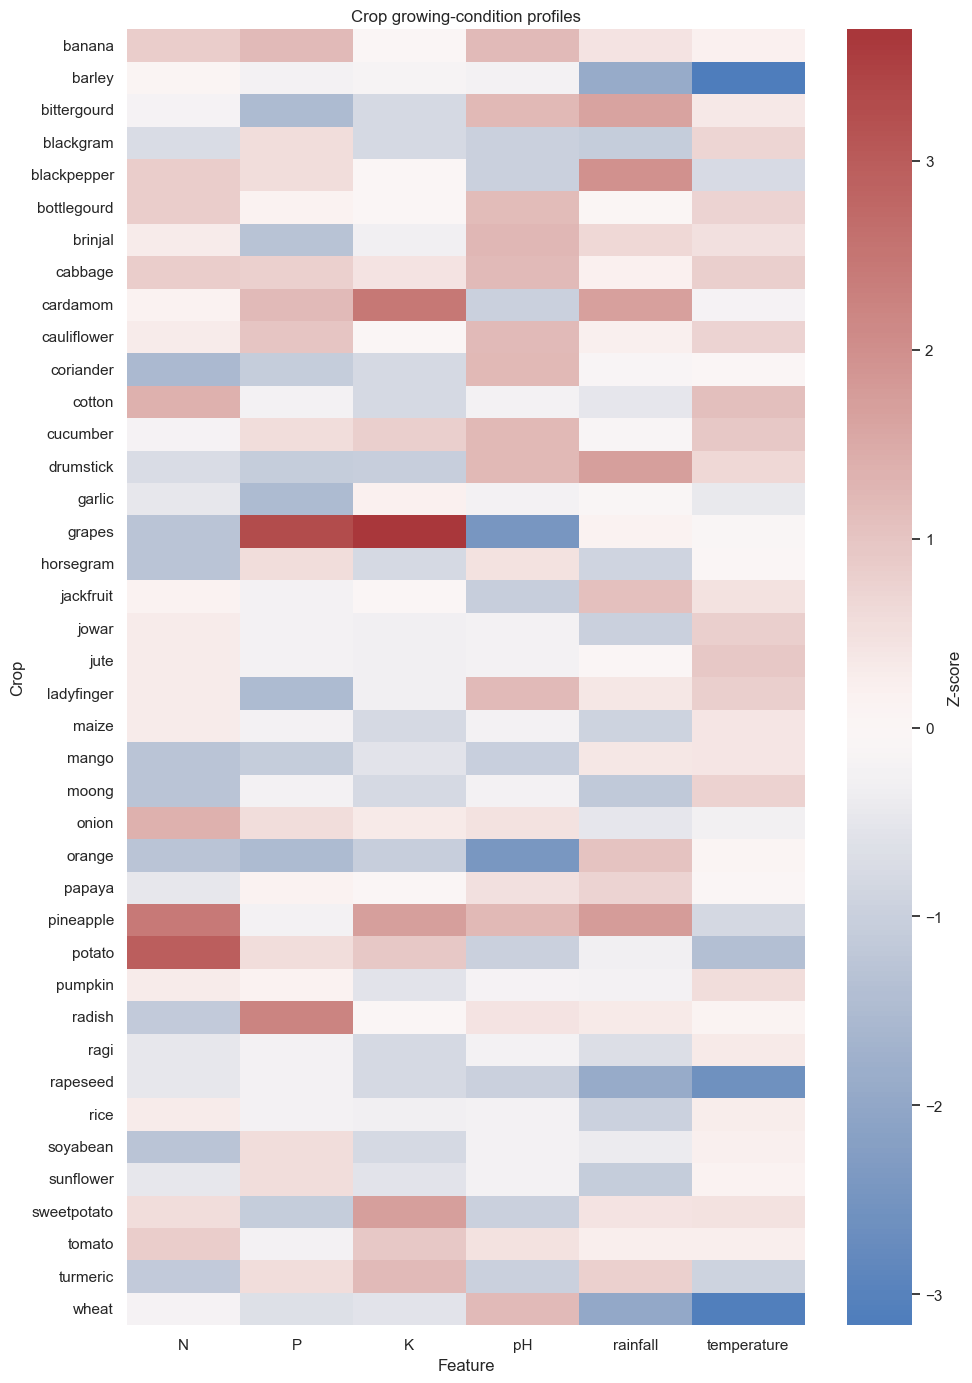

In [11]:
crop_means = clean.groupby(TARGET, observed=True)[FEATURES].mean()
standardized_means = (crop_means - crop_means.mean()) / crop_means.std(ddof=0)

fig, ax = plt.subplots(figsize=(10, 14))
sns.heatmap(standardized_means, cmap="vlag", center=0, ax=ax, cbar_kws={"label": "Z-score"})
ax.set(title="Crop growing-condition profiles", xlabel="Feature", ylabel="Crop")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "crop_feature_profiles.png", dpi=160, bbox_inches="tight")
plt.show()

## 8. Findings and modeling implications

- The supplied train and test files contain the same records in different orders, so they cannot be used as an independent evaluation pair.
- The exported `Unnamed: 0` field is an identifier and must never be used as a feature.
- Exact duplicate feature/target rows are removed before splitting to prevent the same observation appearing in both training and evaluation data.
- The target contains many crop classes and is imbalanced. Use a stratified split and compare macro F1, balanced accuracy, and accuracy.
- Rainfall has a much wider range than the other numeric variables. Scaling is required for distance- or linear-based models and unnecessary for most tree models.
- Humidity and location are absent. The first model must use only `N`, `P`, `K`, `pH`, rainfall, and temperature. Adding unsupported fields directly would create false precision.
- Model training should save the complete preprocessing-and-model pipeline, along with feature names and evaluation metadata.

In [12]:
assert clean.columns.tolist() == REQUIRED_COLUMNS
assert clean[TARGET].notna().all()
assert clean[FEATURES].notna().all().all()
assert not clean.duplicated(subset=REQUIRED_COLUMNS).any()
assert clean["pH"].between(0, 14).all()
assert CLEAN_PATH.exists()

print("All data-quality assertions passed.")
print(f"Clean modeling rows: {len(clean):,}")
print(f"Crop classes: {clean[TARGET].nunique()}")

All data-quality assertions passed.
Clean modeling rows: 7,165
Crop classes: 40
